In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import json
import seaborn as sns

PATH_TO_CONSTANTS = "../../"

with open(PATH_TO_CONSTANTS +"constants.json") as f:
    CONSTANTS = json.load(f)



In [2]:

# Load nodes and edges CSV files
nodes_file = PATH_TO_CONSTANTS + CONSTANTS['cleaned_nodes_csv']
edges_file = PATH_TO_CONSTANTS + CONSTANTS['edges_csv']  # Replace with your edges CSV file path

# Load nodes and edges into DataFrames
nodes_df = pd.read_csv(nodes_file)
edges_df = pd.read_csv(edges_file)

edges_df = edges_df[edges_df['type'] != 'has_code'] #drop the has_code stuff
# Create a directed graph
G = nx.DiGraph()


In [3]:
len(nodes_df) - nodes_df['name'].notna().sum()

3282

In [4]:
nodes_df_clean = nodes_df[nodes_df['name'].isna()]
# nodes_df_clean.iloc[-1].properties

In [5]:
nodes_df_clean.groupby('type').count()

#indication protein and side_effet

,Unnamed: 0,id,properties,properties_dict,name
type,,,,,
code,3280,3280,3280,3280,0
disease,1,1,1,1,0
pathway,1,1,1,1,0


In [6]:
nodes_df_clean = nodes_df[nodes_df['name'].notna()]
nodes_df_clean

,Unnamed: 0,id,type,properties,properties_dict,name
0,0,COMPOUND:1,compound,"{""DRUGBANK"":""DB00001"",""ATC"":""B01AE02"",""DRUGS P...","{'DRUGBANK': 'DB00001', 'ATC': 'B01AE02', 'DRU...",Lepirudin
2,2,COMPOUND:2,compound,"{""DRUGBANK"":""DB00002"",""ATC"":""L01FE01"",""DRUGS P...","{'DRUGBANK': 'DB00002', 'ATC': 'L01FE01', 'DRU...",Cetuximab
4,4,COMPOUND:3,compound,"{""DRUGBANK"":""DB00003"",""ATC"":""R05CB13"",""DRUGS P...","{'DRUGBANK': 'DB00003', 'ATC': 'R05CB13', 'DRU...",Dornase_alfa
6,6,COMPOUND:4,compound,"{""DRUGBANK"":""DB00004"",""ATC"":""L01XX29"",""PUBCHEM...","{'DRUGBANK': 'DB00004', 'ATC': 'L01XX29', 'PUB...",Denileukin_diftitox
8,8,COMPOUND:5,compound,"{""DRUGBANK"":""DB00005"",""ATC"":""L04AB01"",""DRUGS P...","{'DRUGBANK': 'DB00005', 'ATC': 'L04AB01', 'DRU...",Etanercept
...,...,...,...,...,...,...
88932,88932,PROTEIN:22090,protein,"{""UNIPROTKB"":""Q15935;Q86XJ3;Q9NPP0"",""EMBL"":""BC...","{'UNIPROTKB': 'Q15935;Q86XJ3;Q9NPP0', 'EMBL': ...",Zinc finger protein 77
88933,88933,PROTEIN:22091,protein,"{""UNIPROTKB"":""Q15937;Q5VVW1;Q96NV1"",""EMBL"":""AK...","{'UNIPROTKB': 'Q15937;Q5VVW1;Q96NV1', 'EMBL': ...",Zinc finger protein 79
88934,88934,PROTEIN:22093,protein,"{""UNIPROTKB"":""Q9UDY2;A2A3H9;B7Z2R8;B7Z7T6;F5H3...",{'UNIPROTKB': 'Q9UDY2;A2A3H9;B7Z2R8;B7Z7T6;F5H...,Tight junction protein ZO-2 (Tight junction pr...
88935,88935,PROTEIN:22095,protein,"{""UNIPROTKB"":""Q9H900;B3KVB8;Q6N049;Q8N404;Q96S...",{'UNIPROTKB': 'Q9H900;B3KVB8;Q6N049;Q8N404;Q96...,Protein zwilch homolog


In [7]:
nodes_df_clean['name_length'] = nodes_df_clean['name'].apply(len)

result = nodes_df_clean.groupby('type')['name_length'].mean().reset_index()


# Step 2: Group by 'type' and calculate the average length and count
result = nodes_df_clean.groupby('type').agg(
    avg_name_length=('name_length', 'mean'),
    sample_count=('name', 'count')
).reset_index()

print(result)

           type  avg_name_length  sample_count
0      activity        36.141026            78
1      compound        47.190038         32083
2       disease        42.338184          8933
3        effect        27.818713           171
4          gene        32.011075         13363
5    indication        18.782692          2080
6      molecule        19.680412            97
7       pathway        38.808181          2127
8     phenotype        25.018967          6854
9       protein        43.642399         14505
10  side_effect        18.805183          5364


/tmp/ipykernel_266552/977079551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nodes_df_clean['name_length'] = nodes_df_clean['name'].apply(len)


In [8]:
nodes_df_clean['name_length'].sort_values()

39664      2
37272      2
44209      2
46194      2
37374      2
        ... 
50416    762
58487    762
41876    827
13469    838
8094     950
Name: name_length, Length: 85655, dtype: int64

In [9]:
# Filter data for name lengths greater than 150
outliers_df = nodes_df_clean[nodes_df_clean['name_length'] > 150]

# Group by 'type' and count the occurrences
outliers_count = outliers_df.groupby('type').size()

# Display the result
print(outliers_count)

# outliers_df

type
compound    2539
disease        1
protein      351
dtype: int64


/tmp/ipykernel_266552/735136280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nodes_df_clean['name_length'] = nodes_df_clean['name'].apply(lambda x: min(len(x), 150))
/tmp/ipykernel_266552/735136280.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=nodes_df_clean, x='type', y='name_length', palette="Set2")


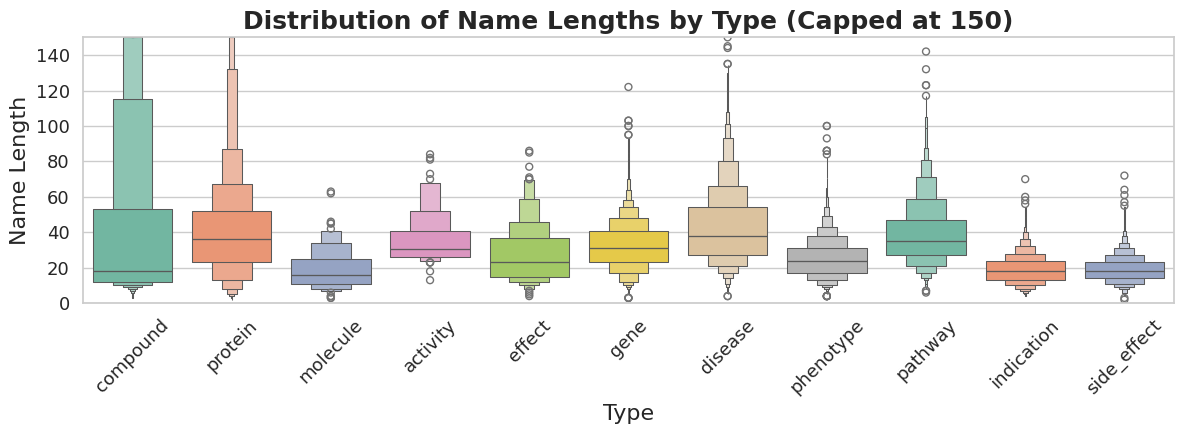

In [10]:
# Cap name lengths at 150
nodes_df_clean['name_length'] = nodes_df_clean['name'].apply(lambda x: min(len(x), 150))

# Set Seaborn style
sns.set_theme(style="whitegrid")

# Boxen plot for better distribution visualization
plt.figure(figsize=(12, 4.5))
sns.boxenplot(data=nodes_df_clean, x='type', y='name_length', palette="Set2")
plt.title('Distribution of Name Lengths by Type (Capped at 150)', fontsize=18, fontweight='bold')
plt.xlabel('Type', fontsize=16)
plt.ylabel('Name Length', fontsize=16)
plt.xticks(rotation=45, fontsize=13)
plt.yticks(fontsize=13)
plt.ylim(0, 150)
plt.tight_layout()
plt.savefig(PATH_TO_CONSTANTS+CONSTANTS['figures']+"Distribution.pdf", format='pdf')  # Export with high resolution
plt.savefig(PATH_TO_CONSTANTS+CONSTANTS['figures']+"Distribution.png", format='png')  # Export with high resolution

plt.show()

